In [1]:
import wget
import os
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.odr import Model, Data, ODR
from scipy.optimize import curve_fit
from astropy.io import fits

from astropy import units as u, constants as const



def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )

def planckcorr(freq_ghz):
    """ Takes in frequency in GHZ and produces factor to be applied to temp """

    freq = freq_ghz * 10.**9.
    CST = {"kbolt": 1.3806488e-23, "light": 2.99792458e8, "plancks": 6.626e-34, "cmb_temp": 2.725}
    factor = CST["plancks"] * freq / (CST["kbolt"] * CST["cmb_temp"])
    correction = (np.exp(factor)-1.)**2. / (factor**2. * np.exp(factor))

    return correction



## Disclaimer 

applying few changes on Mel code for fine reso maps. 
- downgrading maps at `nside=256`
- smoothing maps at `fwhm=1.2 deg`
this is mainly because , there ain't no need to run with `nside=512` (6.9 arcmin), the pixel reso at 256   (13.7 arcmin ) is enough for degree reso . also want to push as much as i could the resolution of maps towards the degree scale. 

Offsets estimated for Q11 in any case are in any case bad. see plot below. 


In [2]:
folder_path = "../ovro_lwa_data"
Path(folder_path).mkdir(parents=True, exist_ok=True)

In [3]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)

    #if beta > -2.1 or beta < -3.5:
    #    plt.plot(xdat, ydat, '.')
    #    plt.plot(xdat, fitted_gradient*xdat +  myoutput.beta[1], 'r-')
    #    plt.show()

    #    print("breaking here")
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]

def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval

def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    #try : 
    #    ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
    #    pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

    #    if pixs[nan1] [0]==0 :
    #        print("Southern Survey ") 
    #        super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
    #    else: 
    #        print("Northern survey ")
    #        super_pixs=  np.arange(pix1) 
    #except IndexError: 
    #    print('Fullsky survey')
    #    super_pixs=  np.arange(hp.nside2npix(nside_superpix ))
    super_pixs=  np.arange(hp.nside2npix(nside_superpix )) #added
    offsets = np.zeros_like(super_pixs)*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)
    
    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            datax = hasmap[patch].value
            datay = map[patch].value

            _, una = np.unique(datay, return_index=True)


            datax = datax[una]
            datay = datay[una]

            errx = haserr[patch].value[una] * datax
            erry =  maperr * datay

            mydata = Data(datax, datay, wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]

            if np.corrcoef(datax, datay)[0,1] > 0.75:
                offsets[jj] = cfit

            else:
    
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 
            
    offmap[super_pixs] = offsets 

    #avec = np.nanmean( offsets ) *map.unit 
    avec = np.nanmedian( offsets ) *map.unit 
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 
 


https://lambda.gsfc.nasa.gov/product/wmap/dr5/ 

https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_get.html



https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/deconv/images/wmap_band_deconv_imap_r9_9yr_K_v5.fits

https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/haslam408_ds_Remazeilles2014.fits

https://lda10g.alliance.unm.edu/LWA1LowFrequencySkySurvey/
https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/healpix-all-sky-rav-wsclean-map-50.fits

https://lambda.gsfc.nasa.gov/product/foreground/fg_rhodes_hart_info.html


In [4]:
#freqs=np.array([
#    36.528, 41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
#    ]) 
freqs=np.array([
    41.760, 46.992, 52.224, 57.456, 62.688, 67.920, 73.152
    ]) 
maps={}
mapserr={}
offerr={}

cwd = Path.cwd() 
for j,fr in enumerate(freqs) :
    if fr == 41.76:
        fstring=(f"ovro_lwa_sky_map_41.760MHz.fits")
    elif fr == 67.92:
        fstring=(f"ovro_lwa_sky_map_67.920MHz.fits")
    else:
        fstring=(f"ovro_lwa_sky_map_{fr}MHz.fits")
    
    try : 
        print(f"reading {fstring} ")
        maps[fr],_=  hp.read_map(f"../ovro_lwa_data/{fstring}" ,h=True  )
    except FileNotFoundError: 
        filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/ovro/{fstring}", out ="../ovro_lwa_data")
        maps[fr]=  hp.read_map(f"../ovro_lwa_data/{fstring}"  )
    
    zeros = np.where(maps[fr] == 0.0)
    maps[fr][zeros] = np.nan 

    maps[fr]*=u.K
    mapserr[fr] = 0.05 # 5 per cent for LWA calibration 
    offerr[fr] = 0.0

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../ovro_lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[408]= (maps[408]*u.K -8.9*u.K ).to(maps[41.760].unit)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr


fstring="GMIMS-HBN_v1_gal_hpx_freq_I.fits"
try :
        
    print(f"reading {fstring} ")

    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fits" ) 
except FileNotFoundError: 
    filename = wget.download( f"https://www.canfar.net/storage/vault/file/AstroDataCitationDOI/CISTI.CANFAR/21.0003/data/release/{fstring}", out ="../lwa_data")
    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fitss" )

header = hdul[0].header
data = hdul[0].data

#horrible RFI - missing data patches before map = 90
maps[1383] = data[90, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1383] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1383]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1383][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1383]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1383][zeros]=np.nan
maps[1383]= (maps[1383]*u.K   ).to(maps[41.760].unit) 
offerr[1383] = 0.0
mapserr[1383] = 0.08 

maps[1418] = data[120, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1418] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1418]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1418][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1418]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1418][zeros]=np.nan
maps[1418]= (maps[1418]*u.K   ).to(maps[41.760].unit) 
offerr[1418] = 0.0
mapserr[1418] = 0.08 

maps[1456] = data[152, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1456] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1456]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1456][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1456]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1456][zeros]=np.nan
maps[1456]= (maps[1456]*u.K   ).to(maps[41.760].unit) 
offerr[1456] = 0.0
mapserr[1456] = 0.08 

maps[1487] = data[180, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1487] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1487]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1487][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1487]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1487][zeros]=np.nan
maps[1487]= (maps[1487]*u.K   ).to(maps[41.760].unit) 
offerr[1487] = 0.0
mapserr[1487] = 0.08 

maps[1499] = data[190, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1524] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1524]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1524][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1524]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1524][zeros]=np.nan
maps[1499]= (maps[1499]*u.K   ).to(maps[41.760].unit) 
offerr[1499] = 0.0
mapserr[1499] = 0.08 

maps[1521] = data[209, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1556] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1556]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1556][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1556]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1556][zeros]=np.nan
maps[1521]= (maps[1521]*u.K   ).to(maps[41.760].unit) 
offerr[1521] = 0.0
mapserr[1521] = 0.08

maps[1614] = data[285, :]
#dat1[outs] = hp.UNSEEN
##outs = np.where(np.isnan(dat1))
#maps[1628] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1628]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1628][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1628]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1628][zeros]=np.nan
maps[1614]= (maps[1614]*u.K   ).to(maps[41.760].unit) 
offerr[1614] = 0.0
mapserr[1614] = 0.08 

maps[1625] = data[300, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1609] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1609]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1609][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1609]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1609][zeros]=np.nan
maps[1625]= (maps[1625]*u.K   ).to(maps[41.760].unit) 
offerr[1625] = 0.0
mapserr[1625] = 0.08 

maps[1660] = data[330, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1660] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1660]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1660][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1660]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1660][zeros]=np.nan
maps[1660]= (maps[1660]*u.K   ).to(maps[41.760].unit) 
offerr[1660] = 0.0
mapserr[1660] = 0.08 

maps[1700] = data[358, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1700] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1700]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1700][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1700]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1700][zeros]=np.nan
maps[1700]= (maps[1700]*u.K   ).to(maps[41.760].unit) 
offerr[1700] = 0.0
mapserr[1700] = 0.08 

maps[1712] = data[368, :]
#outs = np.where(np.isnan(dat1))
#dat1[outs] = hp.UNSEEN
#maps[1749] = rotate_map(dat1, 'G', 'C')
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1749]) , theta1=np.radians(0), theta2 =np.radians(5))
#maps[1749][zeros]=np.nan
#zeros  = hp.query_strip(nside=hp.get_nside(maps[1749]) , theta1=np.radians(120), theta2 =np.radians(180))
#maps[1749][zeros]=np.nan
maps[1712]= (maps[1712]*u.K   ).to(maps[41.760].unit) 
offerr[1712] = 0.0
mapserr[1712] = 0.08 

nside=256 # hp.get_nside(maps[408] )
npix= hp.nside2npix(nside)

reading ovro_lwa_sky_map_41.760MHz.fits 
reading ovro_lwa_sky_map_46.992MHz.fits 
reading ovro_lwa_sky_map_52.224MHz.fits 
reading ovro_lwa_sky_map_57.456MHz.fits 
reading ovro_lwa_sky_map_62.688MHz.fits 
reading ovro_lwa_sky_map_67.920MHz.fits 
reading ovro_lwa_sky_map_73.152MHz.fits 
reading haslam408_ds_Remazeilles2014.fits 
reading GMIMS-HBN_v1_gal_hpx_freq_I.fits 


In [5]:
freqs  =  np.array([  k for k in maps.keys()  ])  

fwhms = {#36.528: 19.1*u.arcmin, 
         41.760: 17.5 *u.arcmin , 
         46.992: 16.3*u.arcmin,
         52.224: 15.2*u.arcmin,
         57.456: 14.9*u.arcmin,
         62.688: 15.0*u.arcmin,
         67.920: 15.0*u.arcmin,
         73.152: 15.1*u.arcmin,
         408.: 56.*u.arcmin,
         1280: 40.*u.arcmin,
         1315: 40.*u.arcmin,
         1349: 40.*u.arcmin,
         1383: 40.*u.arcmin,
         1418: 40.*u.arcmin,
         1456: 40.*u.arcmin,
         1487: 40.*u.arcmin,
         1499: 40.*u.arcmin,
         1521: 40.*u.arcmin,
         1614: 40.*u.arcmin,
         1625: 40.*u.arcmin,
         1660: 40.*u.arcmin,
         1700: 40.*u.arcmin,
         1712: 40.*u.arcmin,
         } 

## smooth maps to 1.0 degrees
fwhmax = 1.0 * 60*u.arcmin
# downgrade them to nside=512
print("smoothing and downgrading maps ")

for k  in freqs:
    nans= np.ma.masked_invalid(maps[k] ).mask
    maps[k] [nans] =hp.UNSEEN *maps[k].unit
    maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside)*maps[k].unit
    if k == 408:
      mapserr[k] = hp.smoothing(mapserr[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
      mapserr[k] = hp.ud_grade(mapserr[k].value , nside_out=nside )*maps[k].unit

    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## Offset removal 

In [6]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

#read Q11 from coarse_parameters.ipynb
file = open("../outputs/offset_coarse.txt")
oldk = []
c_off = []
c_err  = []

for line in file:
    values = line.strip().split()
    oldk.append(float(values[0]))
    c_off.append(float(values[1]))
    c_err.append(float(values[2]))

off11 = np.asarray(c_off)
err11 = np.asarray(c_err)
oldk = np.asarray(oldk)

def process_frequency(k):
    if k > 408:
        theval = np.where(oldk == k)[0][0]
        maps[k] = (maps[k].value - off11[theval])*maps[k].unit
        offset = off11[theval]
        offerr[k] = err11[theval]
        off_map = np.zeros_like(maps[k].value) + off11[theval]
    else:
        maps[k], offset, offerr[k], off_map = remove_off(maps[k], maps[408], mapserr[k], mapserr[408])
    return k, offset, offerr[k], off_map 

# Parallelize the loop
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_frequency, freqs[freqs != 408]), total=len(freqs[freqs != 408])))

# Process results
for k, offset, error_offset,_  in results:
    print(f" {k} MHz data estimated offset: {offset:.4f} ± {error_offset:.4f}")

  0%|          | 0/18 [00:00<?, ?it/s]/opt/anaconda3/envs/env_healpy/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/anaconda3/envs/env_healpy/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/envs/env_healpy/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|██████████| 18/18 [01:09<00:00,  3.88s/it]

 41.76 MHz data estimated offset: -7585.7553 K ± 163.6280
 46.992 MHz data estimated offset: -5455.7263 K ± 125.0505
 52.224 MHz data estimated offset: -4238.6125 K ± 96.8512
 57.456 MHz data estimated offset: -3154.6125 K ± 72.2623
 62.688 MHz data estimated offset: -2606.4027 K ± 58.6423
 67.92 MHz data estimated offset: -2067.4839 K ± 45.1199
 73.152 MHz data estimated offset: -1614.1778 K ± 34.4972
 1383.0 MHz data estimated offset: -0.3929 ± 0.0163
 1418.0 MHz data estimated offset: -0.3280 ± 0.0148
 1456.0 MHz data estimated offset: -0.3115 ± 0.0126
 1487.0 MHz data estimated offset: -0.3193 ± 0.0128
 1499.0 MHz data estimated offset: -0.3106 ± 0.0129
 1521.0 MHz data estimated offset: -0.3387 ± 0.0118
 1614.0 MHz data estimated offset: -0.2792 ± 0.0105
 1625.0 MHz data estimated offset: -0.2379 ± 0.0116
 1660.0 MHz data estimated offset: -0.2596 ± 0.0106
 1700.0 MHz data estimated offset: -0.2220 ± 0.0096
 1712.0 MHz data estimated offset: -0.2169 ± 0.0100


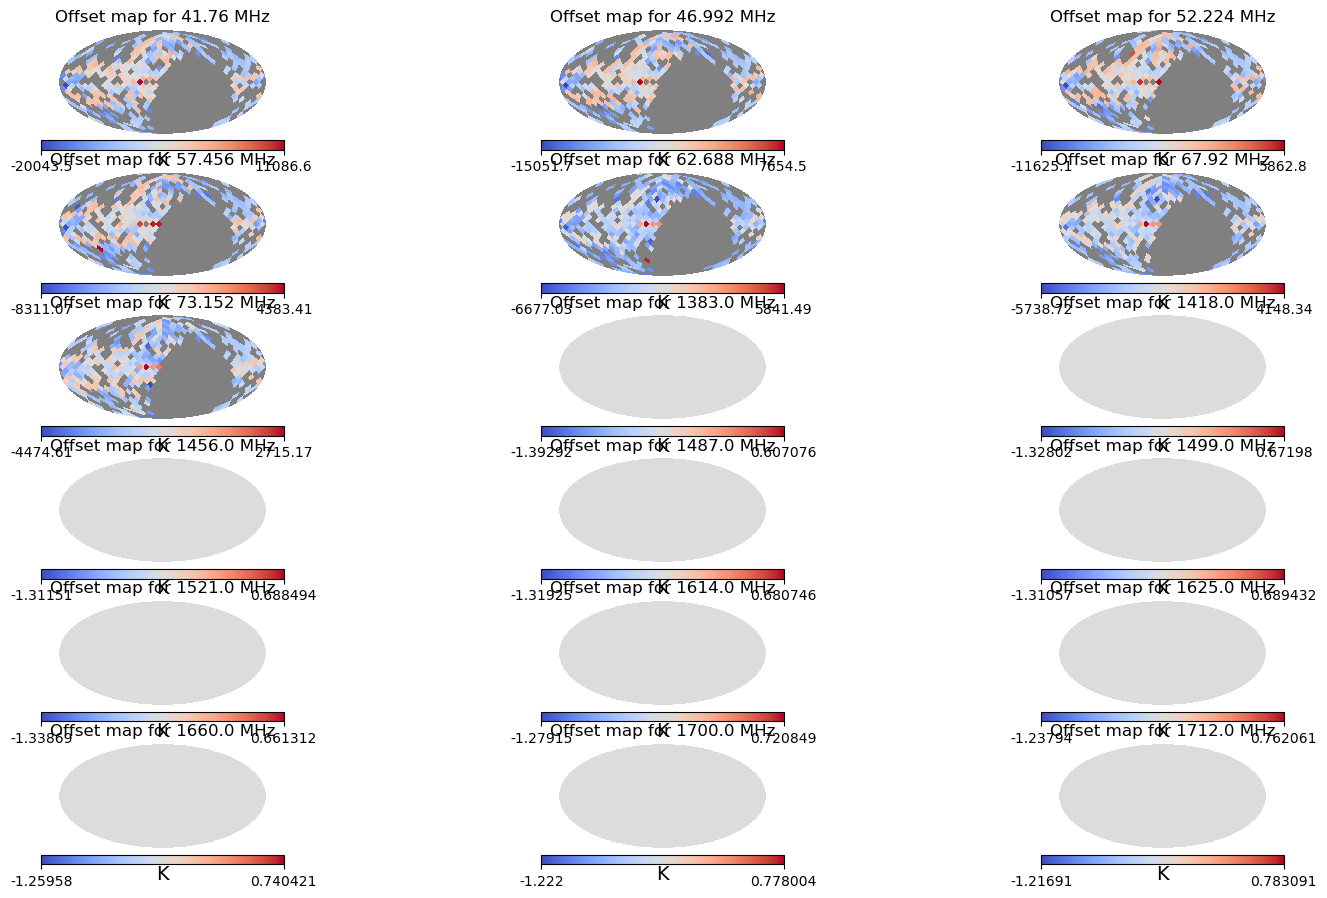

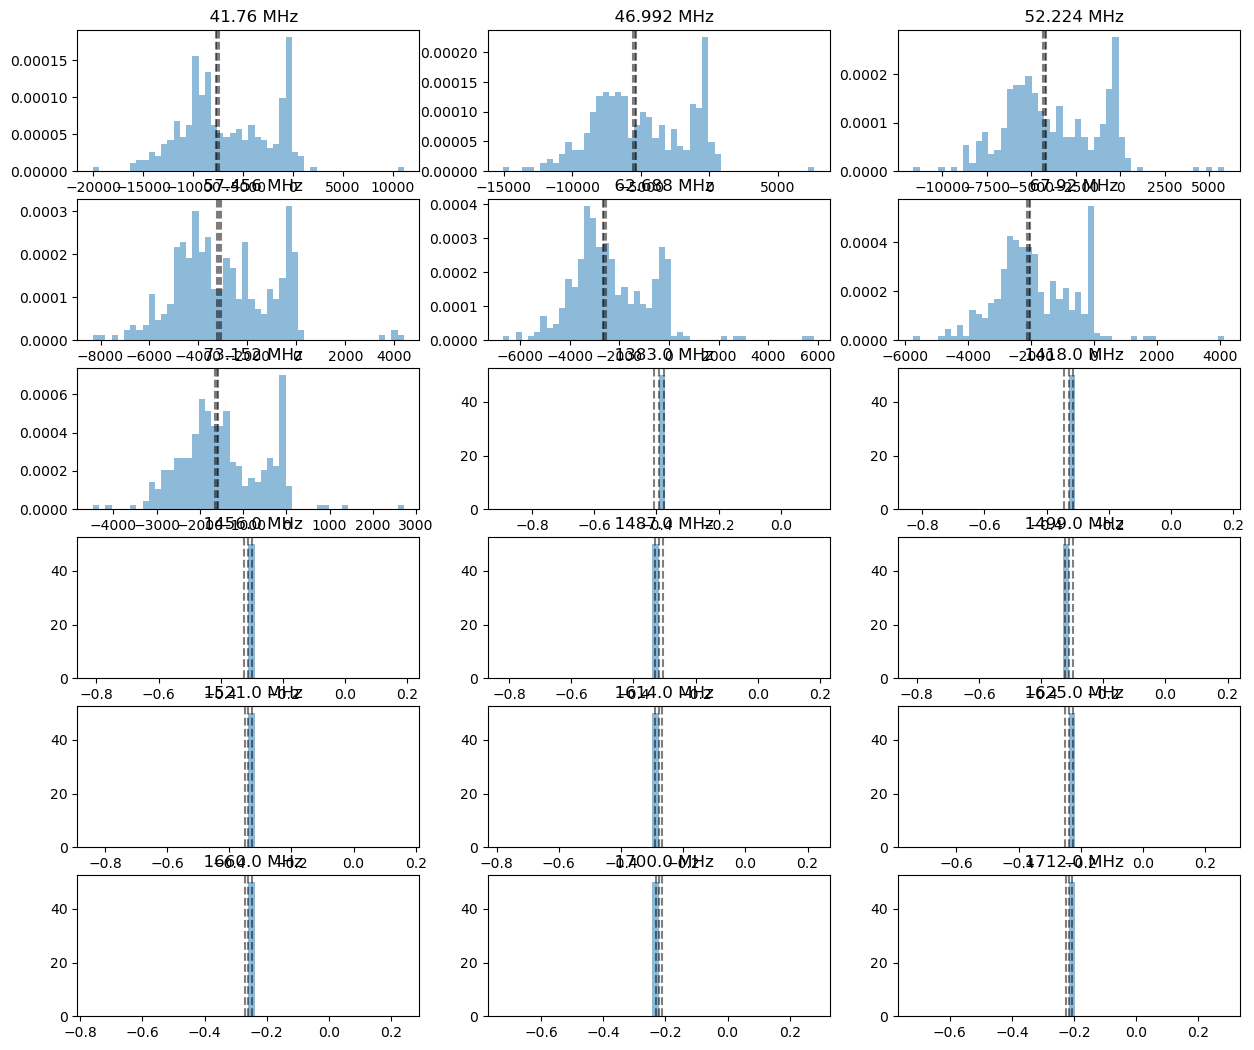

In [7]:
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

j=0
pl.figure(figsize=(15, 10))

for k, offset, error_offset, offset_map  in results:
    hp.mollview(offset_map, title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm', sub=(7,3,j+1))
    j+=1

offset_file = open(output_dir+'/offset_fine.txt', 'w')

pl.figure(figsize=(15, 15))
j=0
for k, offset, error_offset, offset_map  in results:
    try:
        offset_file.write("%f %f % f\n" %(k, offset.value, error_offset))
    except:
        offset_file.write("%f %f % f\n" %(k, offset, error_offset))
    pl.subplot(7, 3, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(offset_map ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    try:
        pl.axvline ( offset.value,ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset.value -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset.value +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    except:
        pl.axvline ( offset, ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
        pl.axvline ( offset +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1

offset_file.close()

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_98301/2254501710.py:5: RuntimeWarning: invalid value encountered in log
  hp.mollview( np.log(m.value ),  title=f'{fr} MHz'  , sub=(7,3,1+j) , notext=True)


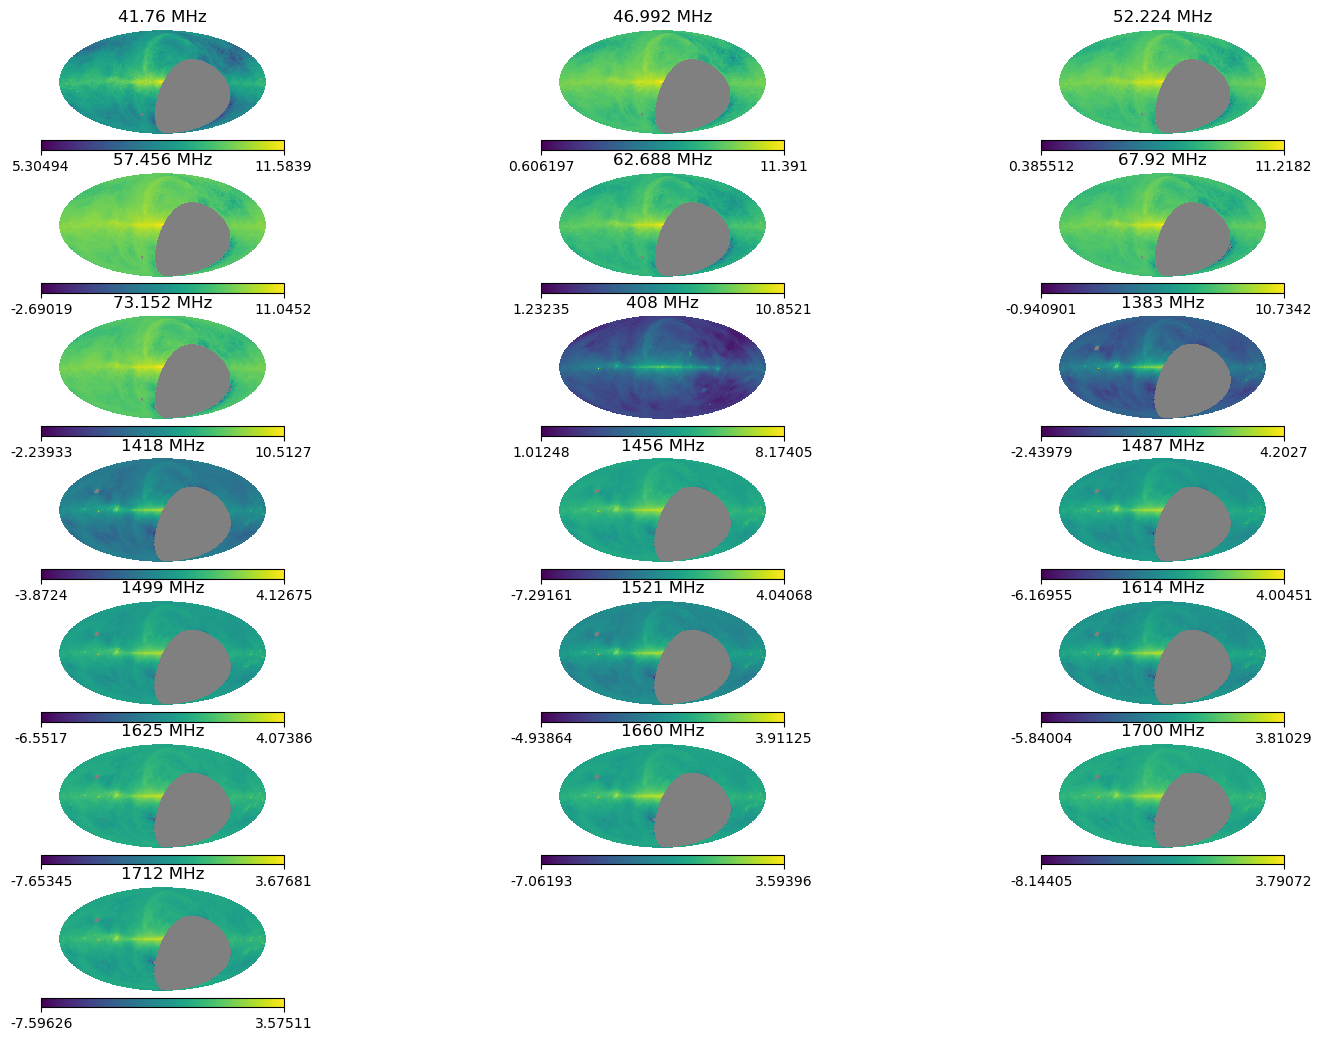

In [8]:
pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview( np.log(m.value ),  title=f'{fr} MHz'  , sub=(7,3,1+j) , notext=True)
    
    j+=1


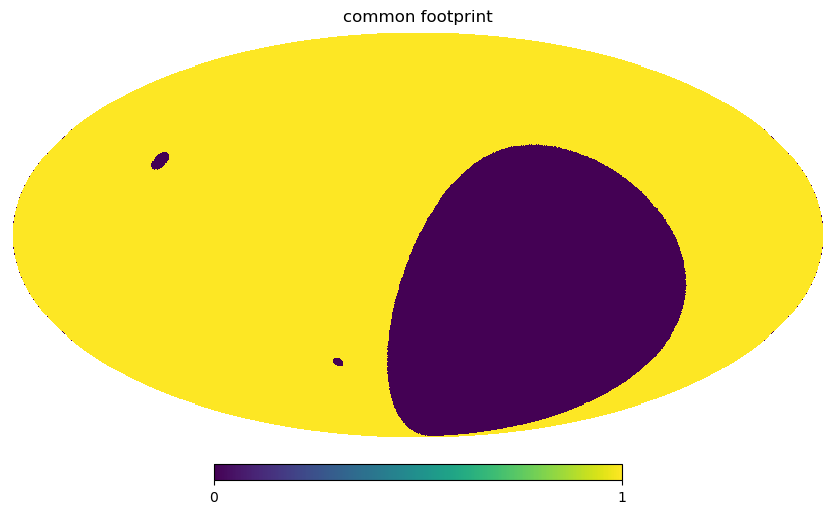

In [9]:
lwa_nans = np.ma.masked_invalid(maps[41.760] ).mask
#chipass_nans = np.ma.masked_invalid(maps[1400] ).mask   
#jonas_nans = np.ma.masked_invalid(maps[2326]).mask
quijote_mask=  np.ma.masked_invalid(maps[1614]).mask
#common_footprint = np.logical_and(np.logical_and(~lwa_nans, ~chipass_nans) , ~jonas_nans) #, ~quijote_mask)  
common_footprint =  np.logical_and(~lwa_nans , ~quijote_mask)  
hp.mollview(common_footprint, title='common footprint' )


In [10]:
fstring="COM_CompMap_freefree-commander_0256_R2.00.fits"
try :
    print(f"reading {fstring} ")
    tmp=  hp.read_map(filename=f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )  
except FileNotFoundError: 
    filename = wget.download( f"http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_freefree-commander_0256_R2.00.fits" , out ="../lwa_data")
    tmp=  hp.read_map(f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )
 
planck_em = tmp[0]* u.cm**-6 *u.pc
planck_te = tmp [1]*u.K 

fstring = "EM_mean_std.fits"
try :
    print(f"reading {fstring} ")
    hust=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://zenodo.org/records/10523170/files/EM_mean_std.fits" , out ="../lwa_data")
    hust =  hp.read_map(f"../lwa_data/{fstring}"    )
hust *= u.cm**-6 *u.pc

reading COM_CompMap_freefree-commander_0256_R2.00.fits 
reading EM_mean_std.fits 


In [11]:

Tff = lambda Te , nu,EM  : Te * (1.0 - np.exp(-tauff(Te,nu, EM ))) 
tauff = lambda Te,nu , EM : 0.05468 *   (Te.value )**-1.5 * (nu.value )**-2 *EM.value   *gff (Te,nu) 
Zi =1 
gff =lambda Te ,nu :  np.log (np.exp(1.0) +np.exp (5.960 -np.sqrt(3)/np.pi *np.log (Zi *nu.to(u.GHz).value *(Te/(1e4*u.K)  )**-1.5  )) )  
free ={} 
for fr in maps.keys() : 
    tmp = Tff(Te=planck_te, nu=(fr*u.MHz).to(u.GHz), EM=hust  )
    tmp = hp.ud_grade(tmp, nside_out=nside)
    if fwhmax !=1 *u.deg: 
        tmp = hp.smoothing(tmp, fwhm=pl.sqrt(fwhmax**2 -  1*u.deg **2 ).to(u.rad).value)
    free[fr]= (tmp)* (maps[41.760].unit)  

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_98301/2615440793.py:5: RuntimeWarning: invalid value encountered in log10
  hp.mollview(  pl.log10(m .value  - (free[fr ].value  )  )   ,  title=f'{fr} MHz'  , sub=(7,3,1+j) , notext=True)


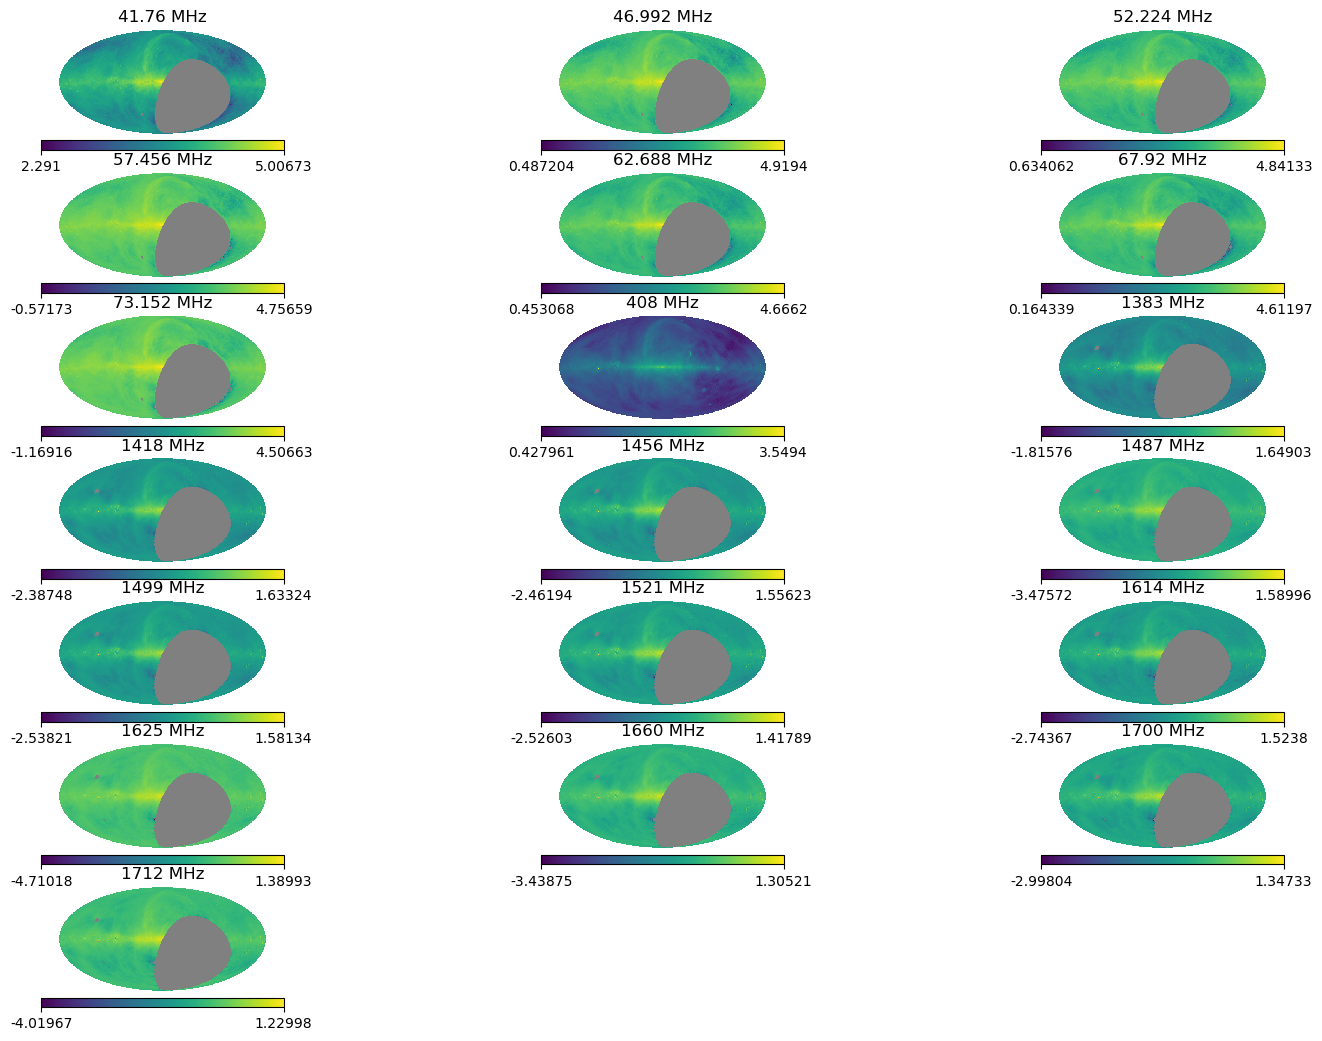

In [12]:
pl.figure(figsize=(15,10)) 
j=0
for fr,m in maps.items():
     
    hp.mollview(  pl.log10(m .value  - (free[fr ].value  )  )   ,  title=f'{fr} MHz'  , sub=(7,3,1+j) , notext=True)
    
    j+=1

pl.show() 

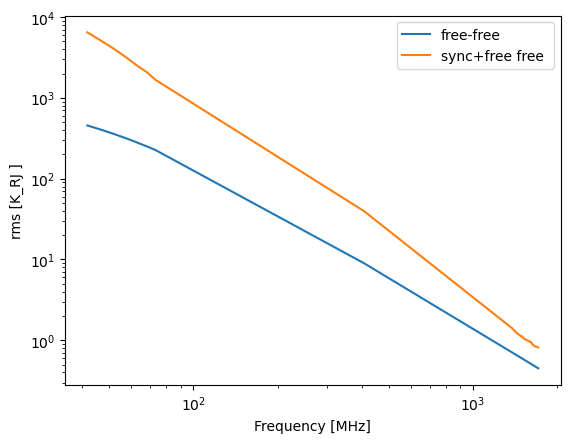

In [13]:
rmsf =np.array( [ np.nanstd(f .value)    for f in free.values() ] ) 
rmsm = np.array( [ np.nanstd(m .value)    for m in maps.values() ] ) 
pl.loglog( freqs, rmsf  ,label='free-free' ,)
pl.loglog( freqs, rmsm  , label='sync+free free ', )

pl.legend()
pl.xlabel('Frequency [MHz]')
pl.ylabel('rms [K_RJ ]')  
pl.show() 


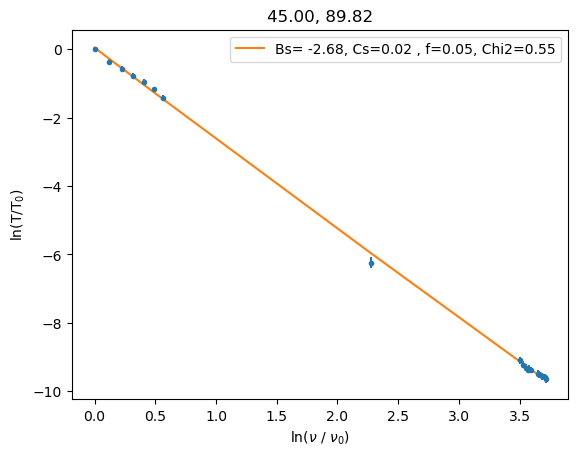

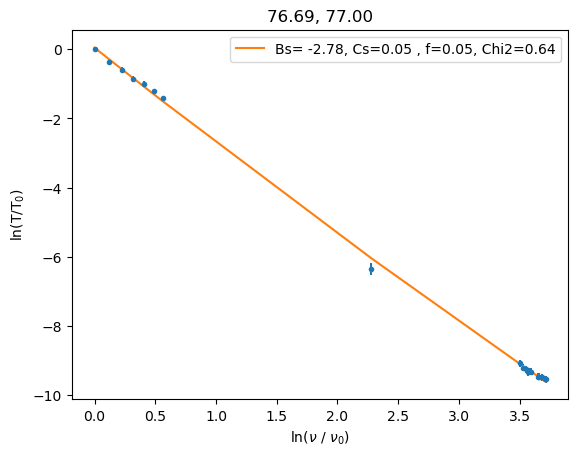

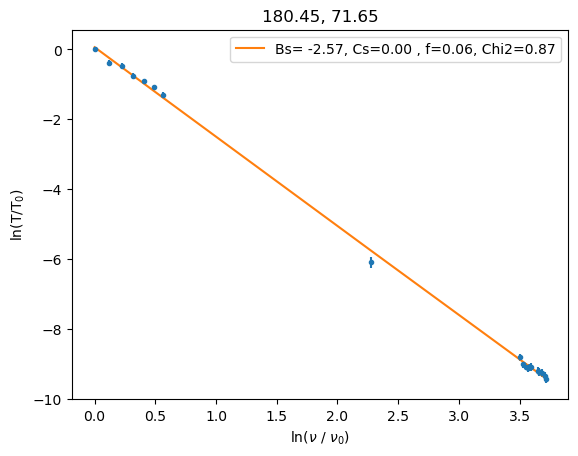

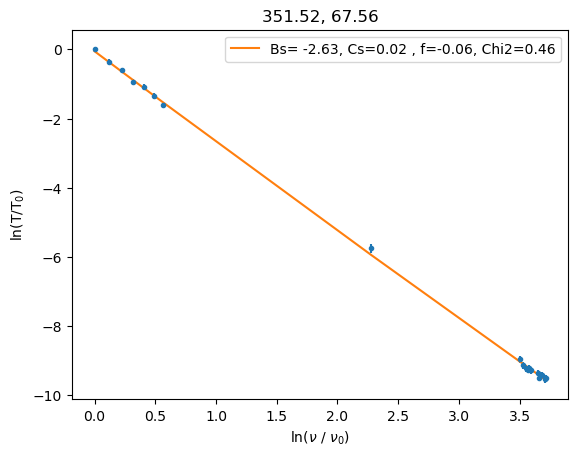

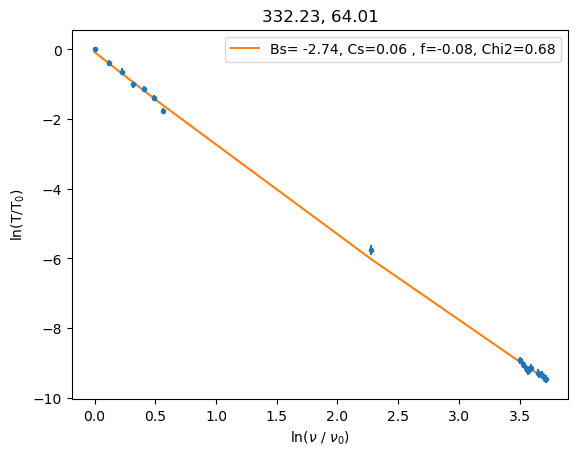

In [14]:
def fitting_beta_curvature(X, beta, cs, const):
    return beta * X + cs * X * X + const

def process_pixel(ipix, return_errors=False):
    ifreq = np.argmin(np.abs(freqs - 36.528))
    pixvals = np.array([(m[ipix].value - free[k][ipix].value) for k, m in maps.items()])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq])
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    p0 = np.array([-3, -0.1, 1])
    ret = np.full(p0.size + 2, np.nan)
    ret[0] = ipix
    errs = np.full(p0.size, np.nan)
    pcov = np.zeros((3, 3)) + np.nan
    if nans.sum():
        return (ret, errs) 
    try:
        popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat, sigma=logyerr, p0=p0)
        ret[-1] = np.sum(((ydat - fitting_beta_curvature(xdat, *popt)) / logyerr) ** 2) / (xdat.size - p0.size)
        ret[1:-1] = popt
        errs = np.sqrt(np.diag(pcov))
        return ret, errs 
    except Exception:
        return ret, errs 

pixel_select = np.arange(npix)[common_footprint]
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)

error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)

ifreq = np.argmin(np.abs(freqs - 36.528))
jj = 0
for ipix in pixel_select[::1000]:
    # Use return_errors=True for error estimation, False for covariance
    fitted_params, error_params = process_pixel(ipix, return_errors=True)
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] = fitted_params[3]
    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = error_params[0]
    error_csmap[ipix] = error_params[1]
    error_fmap[ipix] = error_params[2]
    pixvals = np.array([ (m[ipix].value - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        errm = mapserr[k]
        if isinstance(errm, np.ndarray):
            vals = mapserr[k]
            errm = vals[ipix].value
        pix_errs[cc] = np.sqrt((errm * m[ipix].value)**2 + offerr[k]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    if jj%10==0:
        pl.figure() 
        lon,lat =hp.pix2ang(ipix=ipix, nside=nside,  lonlat=True) 
        pl.title( f"{lon:.2f}, {lat:.2f}" )
        pl.errorbar ( xdat ,  ydat ,
                     yerr= logyerr  ,
                        fmt='.' )
         
        pl.plot(xdat,  fitting_beta_curvature( xdat , *fitted_params[1:-1] ),  
                label =f'Bs= {fitted_params[1]:.2f}, Cs={fitted_params[2]:.2f} , f={fitted_params[3]:.2f}, Chi2={fitted_params[-1]:.2f}' ) 
                #, Bf={fitted_params[4]:.2f}, 

        #pl.semilogx() 
        #pl.loglog() 
        pl.legend()
        pl.xlabel(r"ln($\nu$ / $\nu_{0}$)")
        pl.ylabel(r"ln(T/T$_{0}$)") 
    jj+=1 
    if jj== 50: break

In [15]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

    
# Initialize shared arrays
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)
error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)



# Use ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_pixel, pixel_select), total=len(pixel_select)))

for fitted_params, errs  in results:
    ipix = int(fitted_params[0])  # Ensure ipix is an integer
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] =   fitted_params[3]
    #betafmap[ipix] = fitted_params[4]

    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = errs[0]
    error_csmap[ipix] = errs[1]
    error_fmap[ipix] = errs[2]

    


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_98301/3896950994.py:8: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])
100%|██████████| 585590/585590 [00:04<00:00, 132290.29it/s]


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_98301/4110367950.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


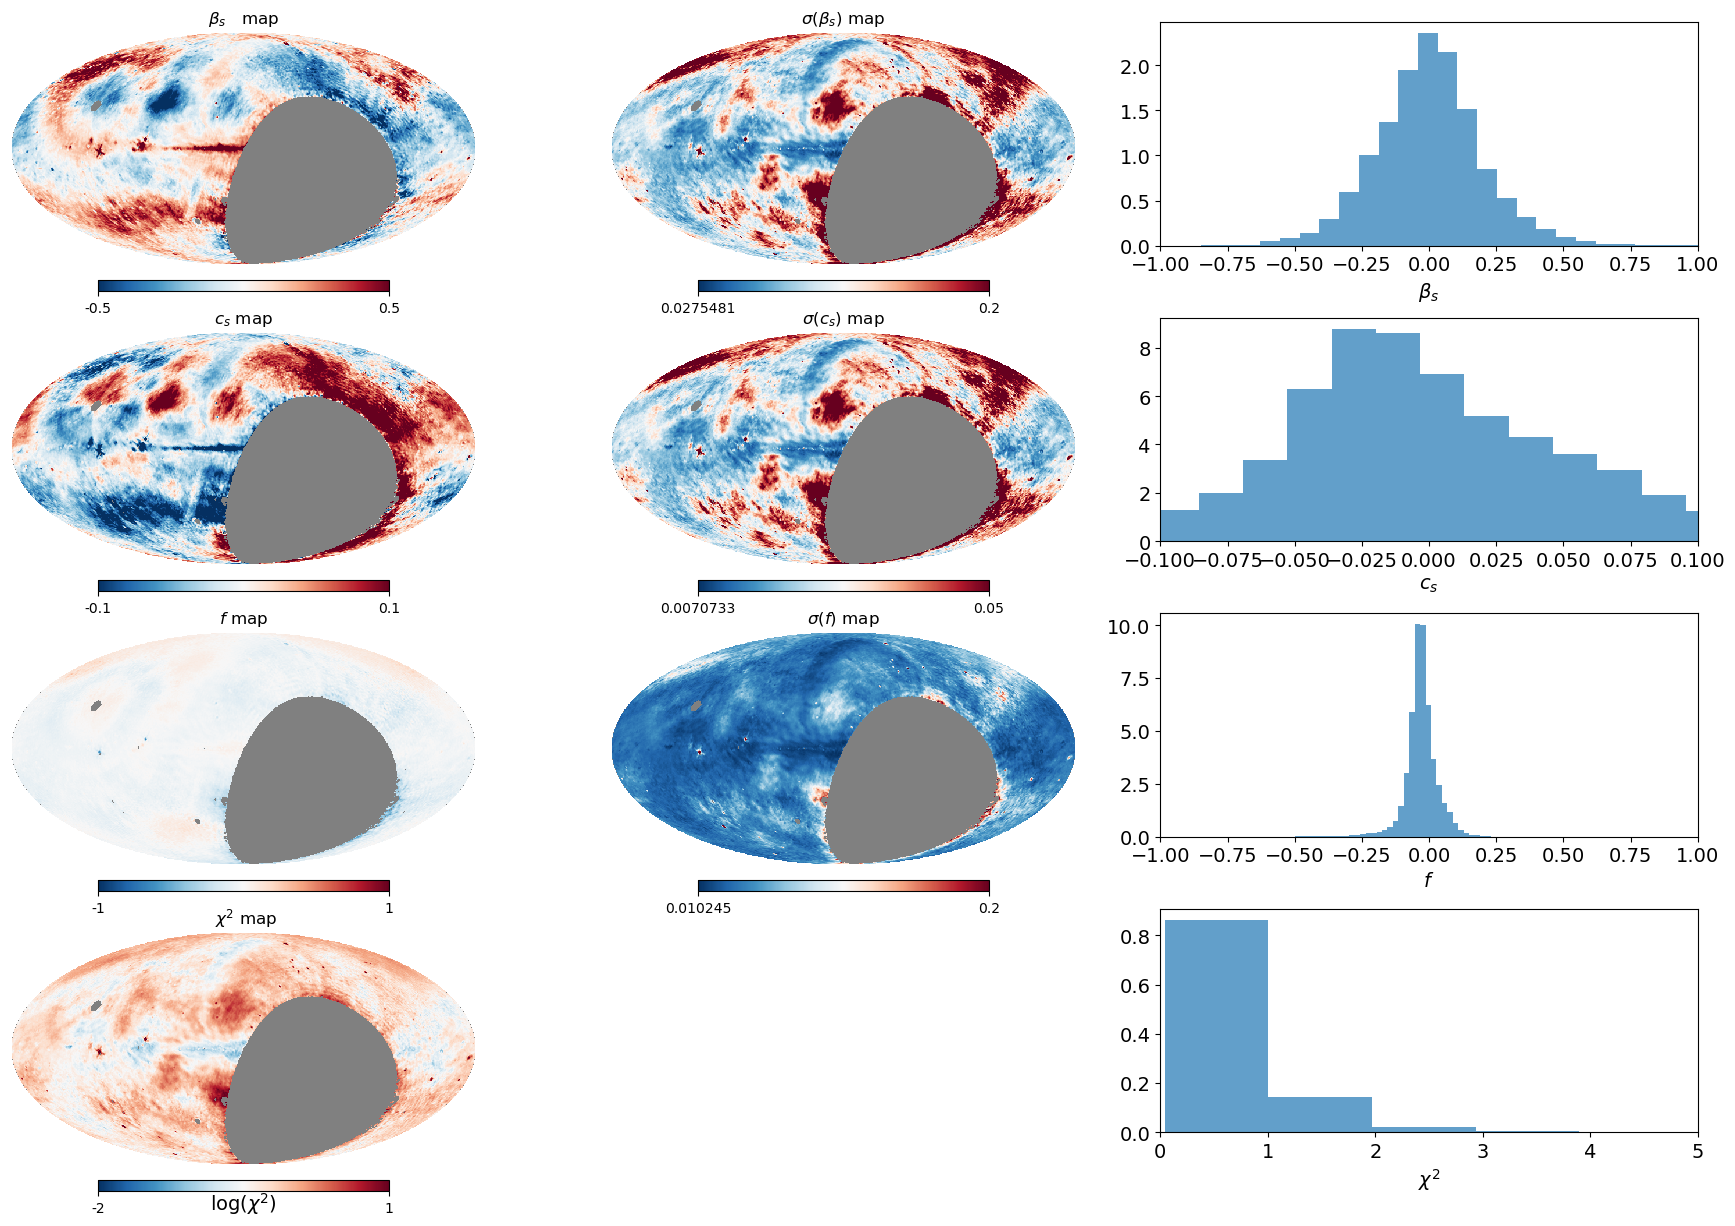

In [16]:
betamap = betamap - np.nanmean(betamap)
csmap = csmap - np.nanmean(csmap)

fig, axes = pl.subplots(4, 3, figsize=(18, 12))

# 1st row: betamap
hp.mollview(betamap, sub=(4, 3, 1), min=-0.5, max=0.5,  cmap='RdBu_r',  notext=True,  title=r'$\beta_s$   map' )
hp.mollview(error_betamap, sub=(4, 3, 2), max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(\beta_s)$ map')
axes[0, 2].hist(betamap[~np.isnan(betamap)], bins=50, density=True, color='C0', alpha=0.7)
axes[0, 2].set_xlabel(r'$\beta_s$', fontsize=14)
#axes[0, 2].set_ylabel('Density')
axes[0, 2].set_xlim( [-1.0, 1.0])
axes[0, 2].tick_params(axis='both', which='major', labelsize=14)
axes[0, 2].tick_params(axis='both', which='minor', labelsize=14)

# 2nd row: csmap

hp.mollview(csmap, sub=(4, 3, 4), min=-0.1, max=0.1,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$c_s$ map')

hp.mollview(error_csmap, sub=(4, 3, 5), max=0.05,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(c_s)$ map')

axes[1, 2].hist(csmap[~np.isnan(csmap)], bins=50, density=True, color='C0', alpha=0.7)
axes[1, 2].set_xlabel(r'$c_s$', fontsize=14)
axes[1, 2].set_xlim( [-.1, .1 ])
axes[1, 2].tick_params(axis='both', which='major', labelsize=14)
axes[1, 2].tick_params(axis='both', which='minor', labelsize=14)

# 3rd row: fmap
hp.mollview(fmap, sub=(4, 3, 7),  cmap='RdBu_r',min=-1,max=1,  notext=True, fig=fig, title=r'$f$ map')
hp.mollview(error_fmap, sub=(4, 3, 8), max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(f)$ map')

axes[2, 2].hist(fmap[~np.isnan(fmap)], bins=50, density=True, color='C0', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[2, 2].set_xlabel(r'$f$', fontsize=14)
axes[2, 2].set_xlim( [-1, 1 ])
axes[2, 2].tick_params(axis='both', which='major', labelsize=14)
axes[2, 2].tick_params(axis='both', which='minor', labelsize=14)

hp.mollview(np.log10(chisquare_map)   , sub=(4,3,10) ,  min=-2 ,max=1,    unit=r'$\log (\chi^2)$',cmap='RdBu_r',notext=True , title=' $\chi^2$ map' ) 
axes[3, 2].hist(chisquare_map[~np.isnan(chisquare_map)], bins=50, density=True, color='C0', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[3, 2].set_xlabel( r'$ \chi^2$', fontsize=14)
axes[3, 2].set_xlim( [0,5 ])
axes[3, 2].tick_params(axis='both', which='major', labelsize=14)
axes[3, 2].tick_params(axis='both', which='minor', labelsize=14)
# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()

pl.savefig('res_1deg.pdf', format='pdf', bbox_inches='tight')

In [17]:
import os 

output_dir = "../outputs"


os.makedirs(output_dir, exist_ok=True)

# Save all maps into a single HEALPix FITS file
hp.write_map(
    f"{output_dir}/bfit_maps_fine.fits",
    [betamap, csmap, fmap, error_betamap , error_csmap, error_fmap , chisquare_map ],
    column_names=["BETAMAP", "CSMAP", "FMAP","BETAMAP_ERR", "CSMAP_ERR", "FMAP_ERR" ,"CHISQUARE"  ],
    overwrite=True,
    dtype=np.float32
)



In [18]:
# Save the common_footprint mask as a HEALPix FITS file
hp.write_map(
    f"{output_dir}/common_mask_fine.fits",
    common_footprint.astype(np.float32),
    overwrite=True,
    dtype=np.float32
)